# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias



## 1. Theoretical Introduction

In modern Digital Signal Processing (DSP) applications, the architecture of digital transceivers is based on the efficient transformation of information for traffic in communication channels. The system performs this interface fundamentally through two essential filtering operations in the physical layer: pulse shaping in transmission and matched filtering in reception.

* **Pulse Shaping (Transmission)**

The generation of the baseband modulated signal consists of mapping the bit source into complex symbols $s_k$ — represented by their in-phase $i_k$ and quadrature $q_k$ components — and interpolating them using a pulse shaping filter $p(t)$. Mathematically, the transmitted signal $s(t)$ in the time domain is expressed as:

$$
s(t)=\sum_{k=-\infty}^{\infty}s_kp(t-kT_s)
$$

To limit the signal's spectral band, the pulse $p(t)$ commonly assumes specific geometries, such as rectangular, raised cosine, or Gaussian.

![Texto Alternativo](images/Tx.png)


* **AWGN Channel**

In the Additive White Gaussian Noise (AWGN) model, the noise is represented by a Gaussian random process. For each instant $t$ in time, the noise $n(t)$ added to the signal is given by a Gaussian random variable with a mean $\mu$ equal to zero and a specific variance $\sigma^2$ . Consequently, the received signal $r(t)$ is modeled as the sum of the transmitted signal and the noise:

$$
r(t)=\sum_{k=-\infty}^{\infty}s_kp(t-kT_s)+n(t)
$$ 

A stationary Gaussian stochastic process characterizes the AWGN channel, which possesses an expected value $\mathbb{E}[n(t)]=0$

![Texto Alternativo](images/Ch.png)

* **Matched Filtering (Reception)**

At the receiver, the signal is degraded by the channel characteristics. To optimize detection, sampling must be preceded by a linear filter (*matched filter*) whose impulse response $h(t)$ is designed to match the transmitted pulse $g(t)$. The matched filter is modeled as the time-reversed and delayed version of the original pulse:

$$
h(t)=g(T_s-t)
$$

This operation correlates the received signal with the expected waveform, maximizing the Signal-to-Noise Ratio (SNR) at the exact sampling instant $t=kT_s$ and reaching the theoretical maximum limit at the filter output of:

$$
SNR=\frac{2\mathbb{E}[|s_k|^2]E_p}{N_0}
$$

![Texto Alternativo](images/Rx.png)


## 2. Project Objectives

This practical activity aims at the implementation and analysis of digital communication systems using the [OptiCommPy](https://github.com/edsonportosilva/OptiCommPy) simulation library. The main objectives of this project are:

* **Baseband Transceiver Modeling:** Develop a functional model of a transmitter (from the generation of binary sequences to the DAC output) and a digital receiver (covering ADC, matched filtering, resampling, symbol detection, and error counting) for $M$-PAM modulation schemes.
* **Performance Evaluation in AWGN Channels:** Analyze the behavior of the modulations under the influence of additive white Gaussian noise, by plotting Bit Error Rate (BER) curves as a function of the Signal-to-Noise Ratio (SNR).
* **Bandwidth Restriction Analysis:** Investigate the deleterious effects and the impact on the overall system performance when signals are subjected to a communication channel with limited bandwidth.

### Imports 

In [137]:
import numpy as np
import matplotlib.pyplot as plt

from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate 
from optic.utils import parameters, dBm2W 
from optic.models.devices import dac, adc
from optic.models.channels import awgn
from optic.plot import eyediagram
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal
import pandas as pd


### Parameters Simulation

In [ ]:
# Rate Sybol
Rs= 10e8

#Sample Per Symbol
SpS= 16

# Sample Rate
Fa= Rs*SpS

#Sample Time
Ta= 1/Fa

#Modulation Order
M= [2,4,16]

#Parameters for Bits Generation
paramBits =  parameters()
paramBits.nBits = 10000
paramBits.mode = 'random'
paramBits.seed = 10

#Parameters for Pulse Shaping
paramPulse = parameters()
paramPulse.pulseType = 'nrz'
paramPulse.SpS = SpS

bits = bitSource(paramBits)
pulse = pulseShape(paramPulse)


t = np.arange(0, pulse.size) * Ta

#Parameters for DAC

j=8 #Um fator de oversampling para garantir que o DAC opere bem acima da taxa de Nyquist do sinal e ajudar no plot
paramDAC = parameters()
paramDAC.inFs = Fa
paramDAC.outFs =  j*Fa
paramDAC.nBits = 12
paramDAC.ENOB = 12
paramDAC.Vpp = 2
paramDAC.AIF= False


paramADC = parameters()
paramADC.inFs = j*Fa  # Sample rate at the input of the ADC, which is the same as the DAC output rate
paramADC.outFs = Fa   # Sample rate at the output of the ADC, which is the original sample rate Fa after decimation
paramADC.nBits = 12   # Number of bits for the ADC
paramADC.ENOB = 12    # Effective Number of Bits, ideally equal to nBits for a perfect ADC
paramADC.Vpp = 2      # Peak-to-peak voltage range of the ADC, matching the DAC's Vpp for optimal quantization
paramADC.AIF = False  # Assuming the ADC does not have an anti-aliasing


paramDec = parameters()
paramDec.SpSin = SpS # Number of samples per symbol at the input of the decision device, which is the same as the original SpS before decimation
paramDec.SpSout = 1 # Number of samples per symbol at the output of the decision device, which is 1 since we want one sample per symbol for decision making



# Transmitter 
### PulseShape for filtering 

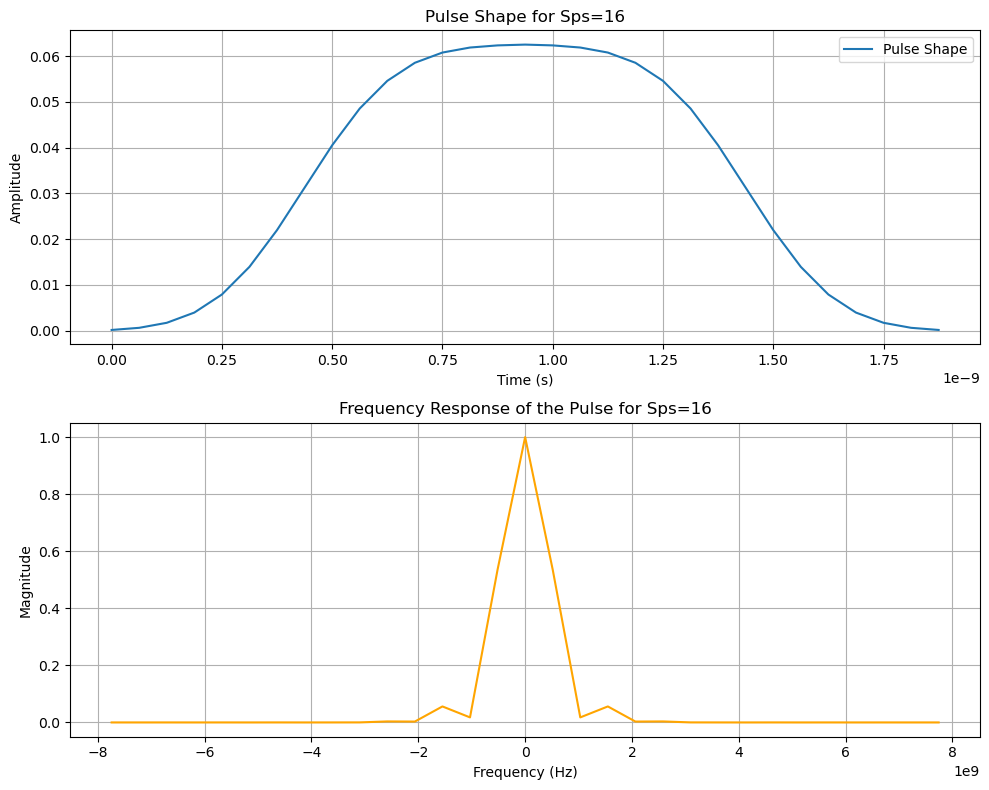

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
    
# Pulse Shape
axs[0].plot(t, pulse, label='Pulse Shape')
axs[0].set_xlabel('Time (s)')          # Note que em subplots usamos set_xlabel
axs[0].set_ylabel('Amplitude')
axs[0].set_title(f'Pulse Shape for Sps={SpS}')
axs[0].grid(True)
axs[0].legend()

# Ftt of the pulse
P = np.fft.fftshift(np.fft.fft(pulse))
freqs = np.fft.fftshift(np.fft.fftfreq(P.size, d=Ta))
    
# Frequency Reponse
axs[1].plot(freqs, np.abs(P), color='orange')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Magnitude')
axs[1].set_title(f'Frequency Response of the Pulse for Sps={SpS}')
axs[1].grid(True)
    
plt.tight_layout()    
plt.show()
  

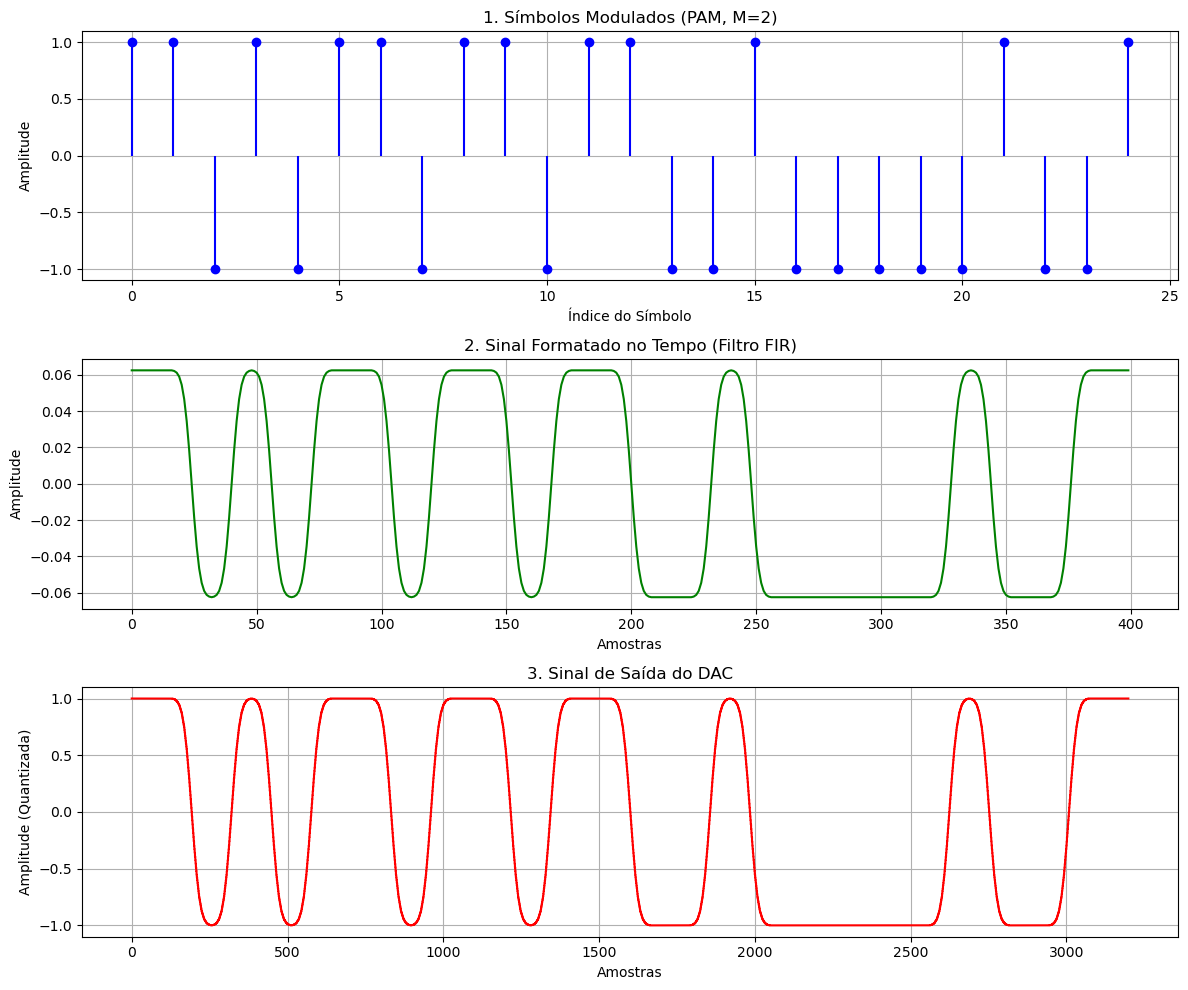

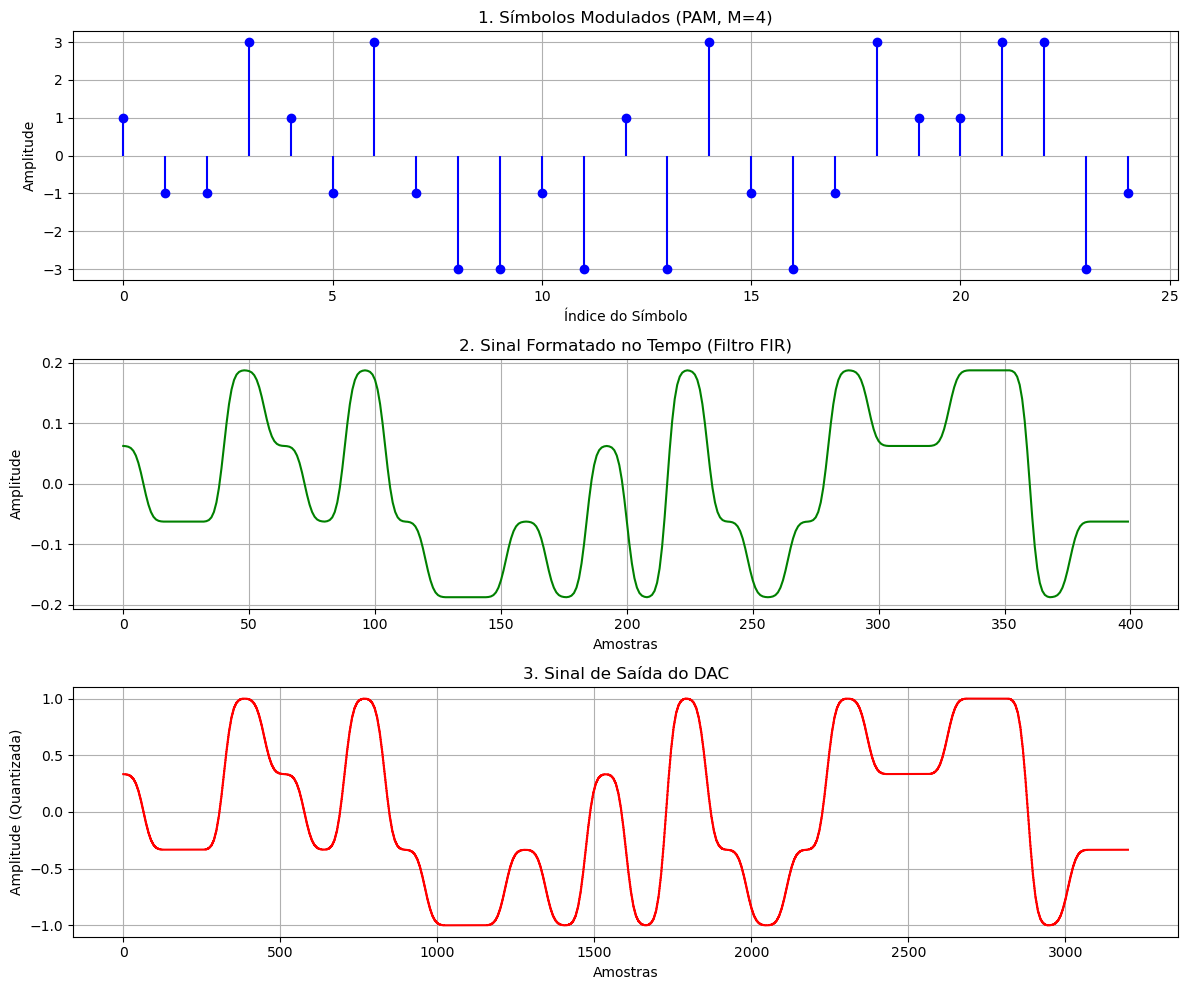

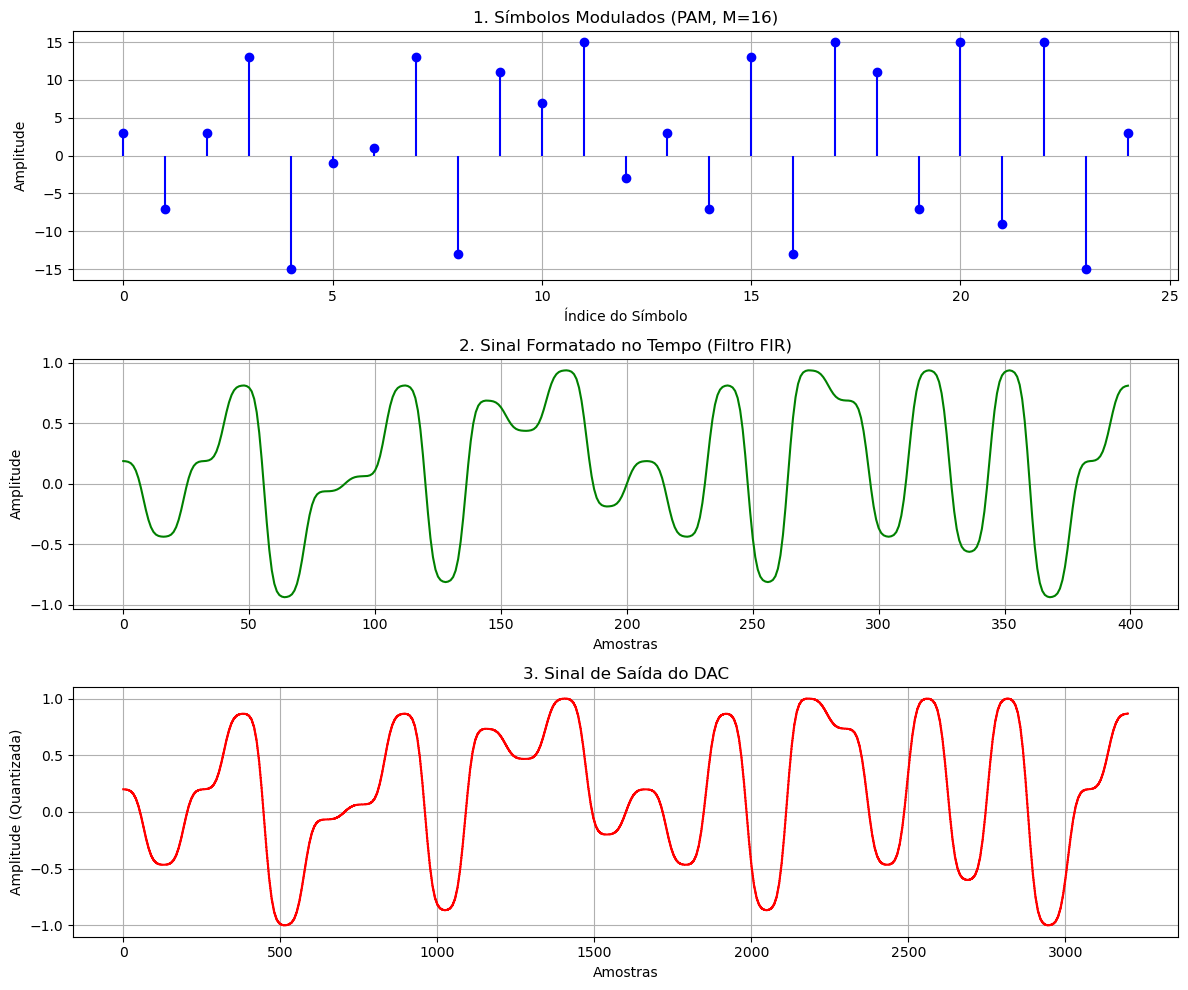

In [5]:
TxSymbols_list = [] 
TxSigDac_list = []

for i in range(len(M)):
    # Mapping 'pam' -> Upsample -> Pulse Shaping -> DAC -> 
    TxSymbols = modulateGray(bits, M[i], 'pam')
    TxSymbolsUp = upsample(TxSymbols, SpS)
    TxSymbols_Pulsed = firFilter(pulse, TxSymbolsUp)
    TxSigDac = dac(TxSymbols_Pulsed, paramDAC) # The DAC's output is the quantized and held version of the pulsed signal, ready for transmission
    
    #Saving the results in lists 
    TxSymbols_list.append(TxSymbols)
    TxSigDac_list.append(TxSigDac)

   
    fig, axs = plt.subplots(3, 1, figsize=(12, 10))
    
    # Limit the number of symbols and samples to plot for better visualization
    num_symbols_to_plot = 25
    num_samples_to_plot = num_symbols_to_plot * SpS 
    
    # Symbols after modulation (PAM)
    axs[0].stem(TxSymbols[:num_symbols_to_plot], basefmt=" ", linefmt='b-', markerfmt='bo')
    axs[0].set_title(f'1. Símbolos Modulados (PAM, M={M[i]})')
    axs[0].set_xlabel('Índice do Símbolo')
    axs[0].set_ylabel('Amplitude')
    axs[0].grid(True)

    # Signal after transmission through the FIR filter (Pulse Shaping)
    axs[1].plot(TxSymbols_Pulsed[:num_samples_to_plot], color='green')
    axs[1].set_title(f'2. Sinal Formatado no Tempo (Filtro FIR)')
    axs[1].set_xlabel('Amostras')
    axs[1].set_ylabel('Amplitude')
    axs[1].grid(True)

    # Signal at the output of the DAC (Quantized and held)
    # Usamos drawstyle='steps-post' para dar aquele aspecto de "escadinha" 
    # típico do processo de quantização e retenção (zero-order hold) de um DAC
    axs[2].plot(TxSigDac[:j*num_samples_to_plot], color='red', drawstyle='steps-post')
    axs[2].set_title(f'3. Sinal de Saída do DAC')
    axs[2].set_xlabel('Amostras')
    axs[2].set_ylabel('Amplitude (Quantizada)')
    axs[2].grid(True)

    # Ajusta os espaçamentos e exibe a figura da iteração atual
    plt.tight_layout()
    plt.show()

### Symbol constellation generated for M-ary

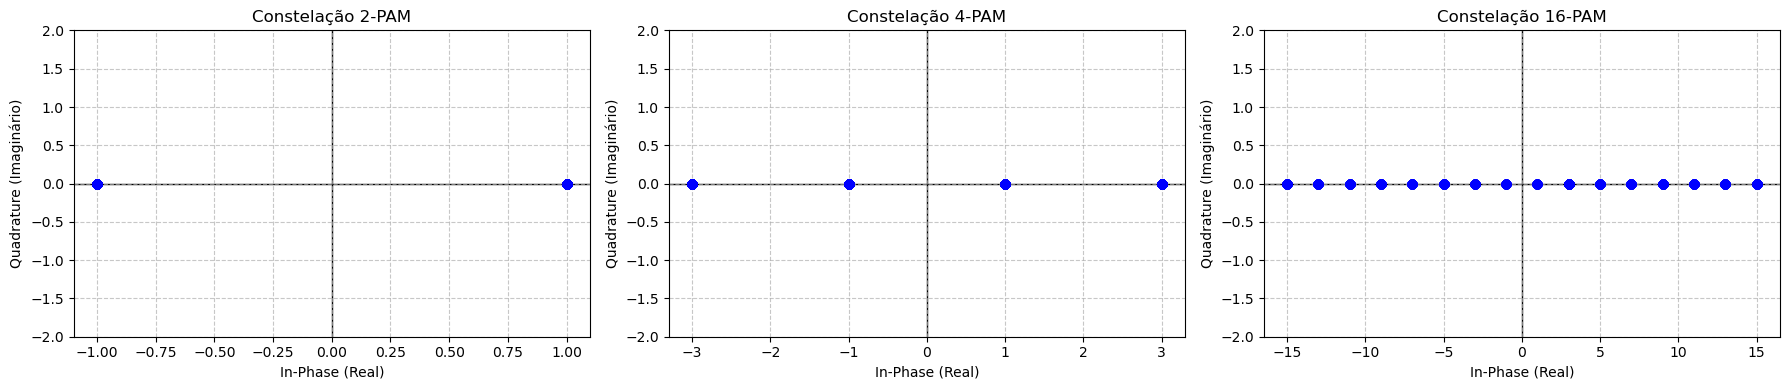

In [6]:
fig, axs = plt.subplots(1, len(M), figsize=(18, 4))

# If M has only one element, axs will not be a list, so we convert it to a list to avoid breaking the 'for' loop
if len(M) == 1:
    axs = [axs]

for i in range(len(M)):
    # Symbols [i] of this M saved in the list before
    symbols = TxSymbols_list[i]
    
    # Ik and Qk
    # In PAM modulation Ik = 0, always.
    axe_i = np.real(symbols)
    axe_q = np.imag(symbols)
    
    # plot
    axs[i].scatter(axe_i, axe_q, color='blue', alpha=0.5, zorder=3)
    
    axs[i].set_title(f'Constelação {M[i]}-PAM')
    axs[i].set_xlabel('In-Phase (Real)')
    axs[i].set_ylabel('Quadrature (Imaginário)')
    
    axs[i].axhline(0, color='black', linewidth=1, zorder=1)
    axs[i].axvline(0, color='black', linewidth=1, zorder=1)
    
    # 
    axs[i].grid(True, linestyle='--', alpha=0.7, zorder=0)
    
    axs[i].set_ylim(-2, 2)

plt.tight_layout()
plt.show()

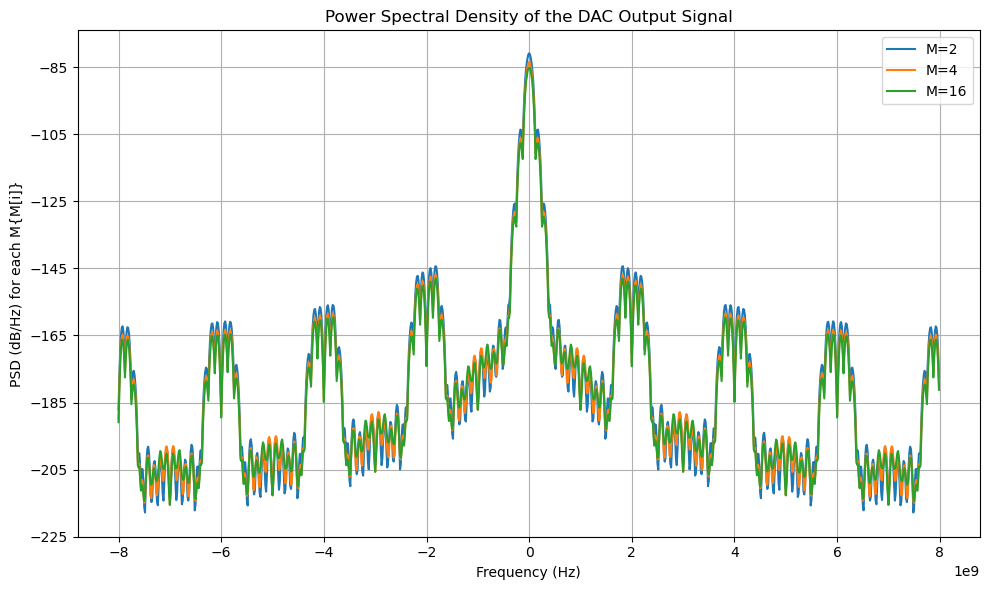

In [88]:
plt.figure(figsize=(10, 6))
for i in range(len(M)):
    plt.psd(TxSigDac_list[i], NFFT=1024, Fs=Fa, label=f'M={M[i]}', color=f'C{i}', sides='twosided')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (dB/Hz) for each M{M[i]}')
    plt.title('Power Spectral Density of the DAC Output Signal')
    plt.grid(True)
    plt.legend()
plt.tight_layout()
plt.show()

### AWGN Channel 

In [112]:
# Signal after through DAC for M=4, extracted from the list created before
CleanSignalM = TxSigDac_list[1]

# Parameters for AWGN Channel
paramAWGN = parameters()

# SNR desired for the AWGN channel (in dB)
paramAWGN.snr = 25

# Sample rate is the same as the DAC output rate, which is j times the original sample rate Fa
paramAWGN.Fs = j*Fa # ou j * Fa

# Reference bandwidth for the signal is the symbol rate Rs, which is the bandwidth that matters for calculating noise power in a digital communication system
paramAWGN.B = Rs  

# Noise type
paramAWGN.complexNoise = False 

# DAC -> AWGN Channel, for the second modulation order (M=4)
TxSig_noisy = awgn(CleanSignalM, 
                      snr=paramAWGN.snr, 
                      Fs=paramAWGN.Fs, 
                      B=paramAWGN.B, 
                      complexNoise=paramAWGN.complexNoise)


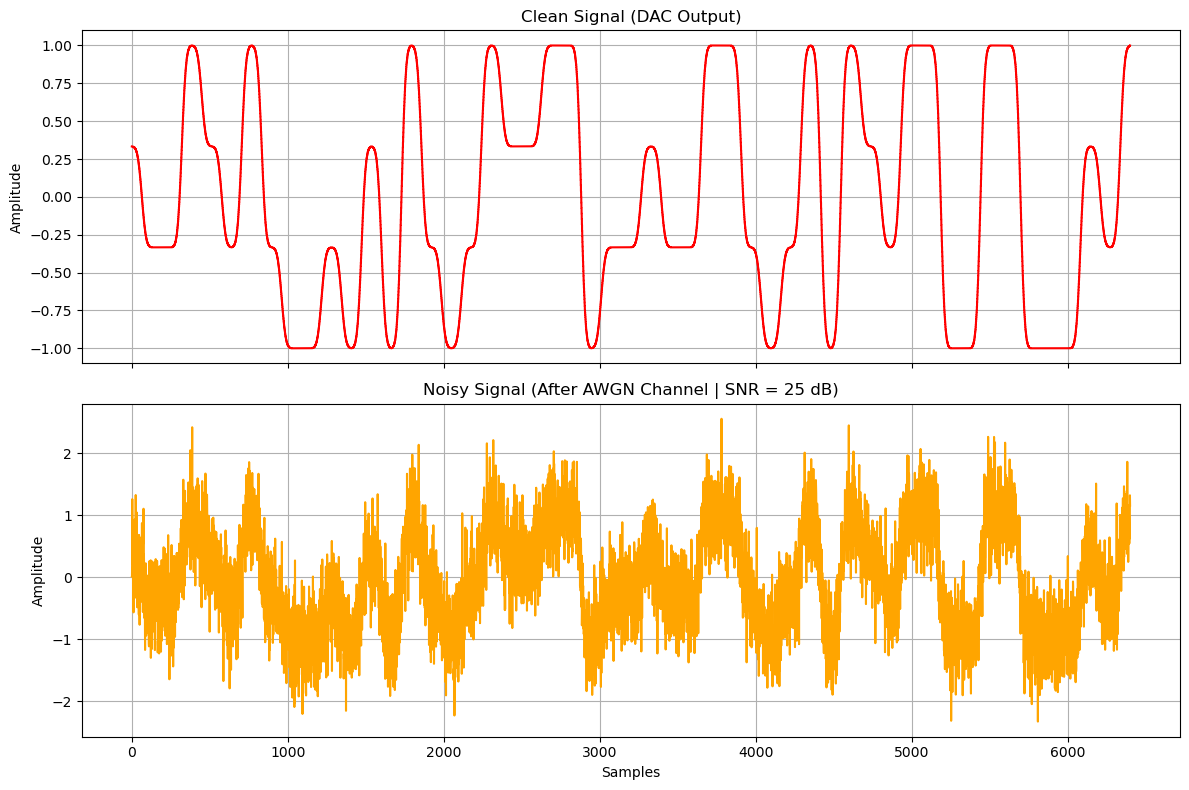

In [113]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 50 samples for better visualization
num_symbols_to_plot = 50
# j is the factor of oversampling for the DAC
dac_samples = num_symbols_to_plot *SpS*j
#  Clean Signal (DAC output)
axs[0].plot(CleanSignalM[:dac_samples], color='red', drawstyle='steps-post')
axs[0].set_title('Clean Signal (DAC Output)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# -Noise Signal After AWGN Channel
# Tiramos o 'steps-post' aqui porque o ruído é um processo contínuo/analógico
axs[1].plot(TxSig_noisy[:dac_samples], color='orange')
axs[1].set_title(f'Noisy Signal (After AWGN Channel | SNR = {paramAWGN.snr} dB)')
axs[1].set_xlabel('Samples')
axs[1].set_ylabel('Amplitude')
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Eye-Diagram for AWGN Channel


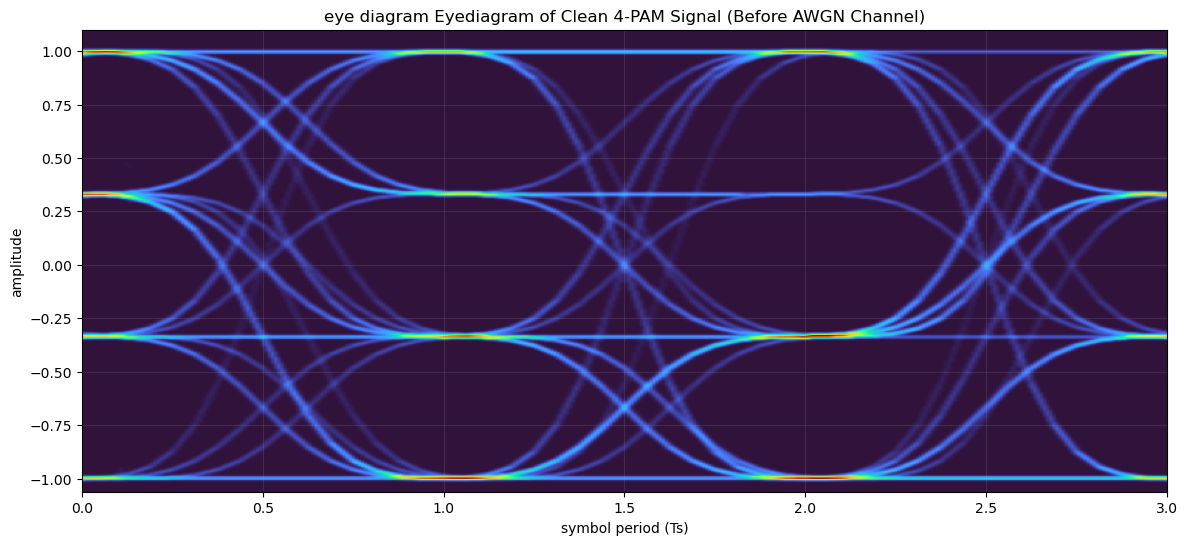

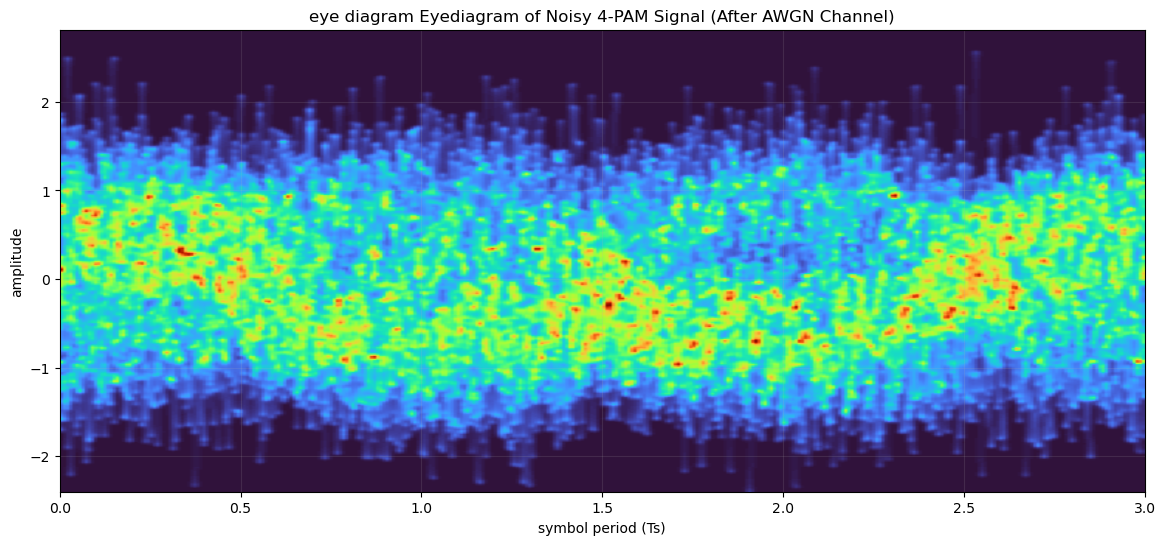

In [151]:
plt.rcParams['figure.figsize'] = (14, 6)

# Parameters for the Eye Diagram
SpS_dac = SpS * j       # SpS after the DAC, which is the original SpS times the oversampling factor j
eye_samples = 10000   # Sample size ideal for rendering fast and looking good

eyediagram(sigIn=CleanSignalM, 
           Nsamples=eye_samples, 
           SpS=SpS_dac, 
           n=3,             # Number of "eyes" side by side (3 is the ideal default)
           ptype='fancy',   # 'fancy' heatmap
           plotlabel=f'Eyediagram of Clean 4-PAM Signal (Before AWGN Channel)')

eyediagram(sigIn=TxSig_noisy, 
           Nsamples=eye_samples, 
           SpS=SpS_dac, 
           n=3,             # Number of "eyes" side by side (3 is the ideal default)
           ptype='fancy',    # 'fancy' heatmap
           plotlabel=f'Eyediagram of Noisy 4-PAM Signal (After AWGN Channel)')



# Receivers

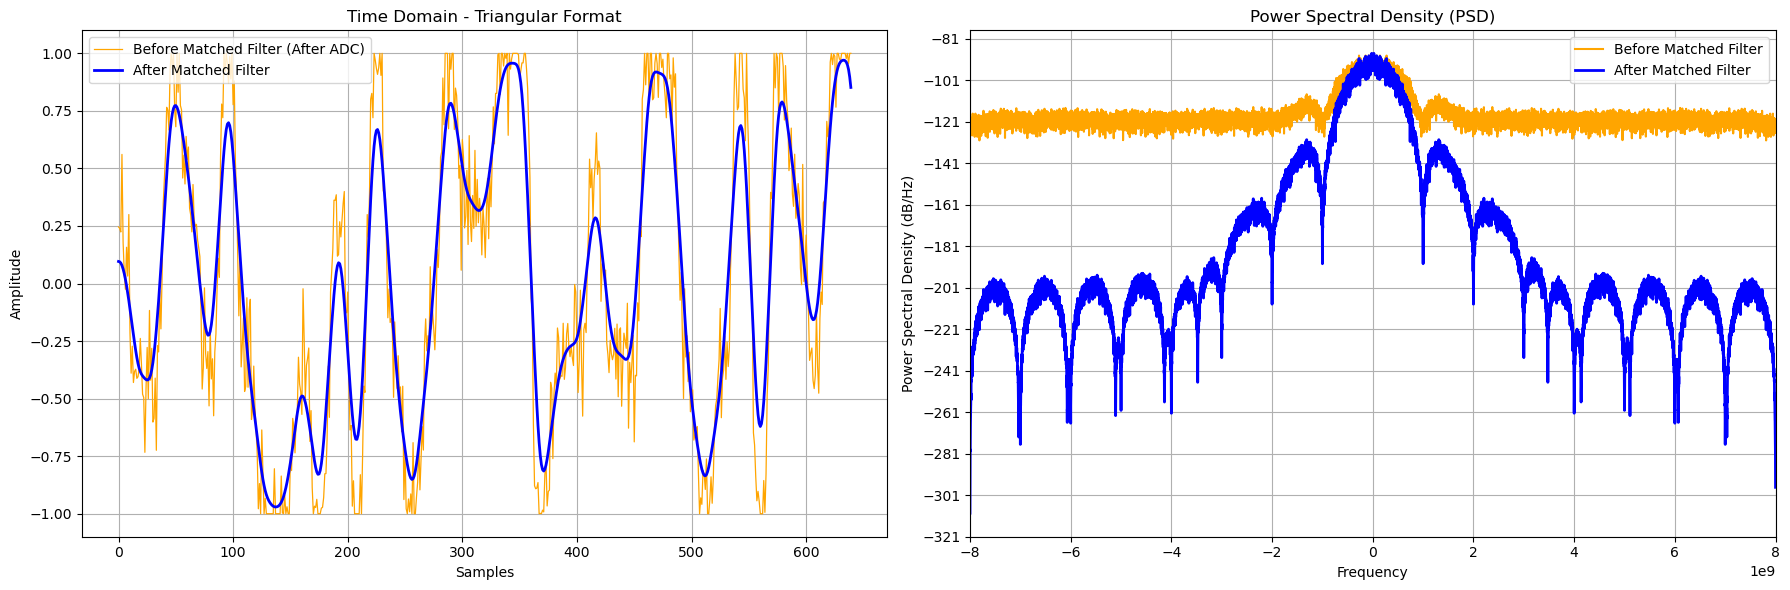

In [ ]:
# Note: The signal transmitted through the AWGN has M[1]= 4 PAM
# Noisy signal after the AWGN channel goes into the ADC
RxSig_ADC = adc(TxSig_noisy, paramADC)

# Matched filter is the time-reversed pulse
pulse_Matched_filter = pulse[::-1]
Rx_Filter_Matched = firFilter(pulse_Matched_filter, RxSig_ADC)

#Decimate the signal after the matched filter to get back to the original sample rate Fa, which is necessary for proper symbol decision and BER calculation later on
Decimated_Symb = decimate(Rx_Filter_Matched, paramDec)

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Time Domain Plot (Limited to 40 symbols for better visualization)
num_symbols = 40
amostras_plot = num_symbols * SpS

# Plot of the noisy signal before the filter (orange) and after the filter (blue)
axs[0].plot(RxSig_ADC[:amostras_plot], color='orange', linewidth=0.9, label='Before Matched Filter (After ADC)')
axs[0].plot(Rx_Filter_Matched[:amostras_plot], color='blue', linewidth=2, label='After Matched Filter')
axs[0].set_title('Time Domain - Triangular Format')
axs[0].set_xlabel('Samples')
axs[0].set_ylabel('Amplitude')
axs[0].legend()
axs[0].grid(True)

# Frequency Domain Plot (PSD)
axs[1].psd(RxSig_ADC, NFFT=2048*8, Fs=Fa, color='orange', label='Before Matched Filter', sides='twosided')
axs[1].psd(Rx_Filter_Matched, NFFT=2048*8, Fs=Fa, color='blue', linewidth=2, label='After Matched Filter', sides='twosided')
axs[1].set_title('Power Spectral Density (PSD)')
# Focusing the visualization on the useful band 
axs[1].set_xlim([-8 * Rs, 8 * Rs])
axs[1].legend()

plt.tight_layout()
plt.show()



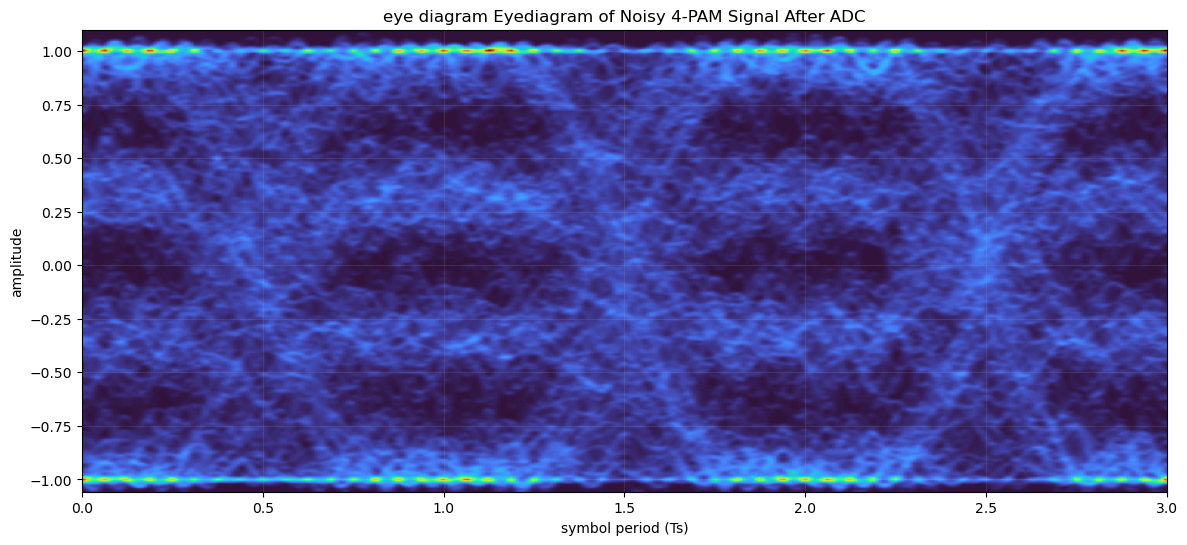

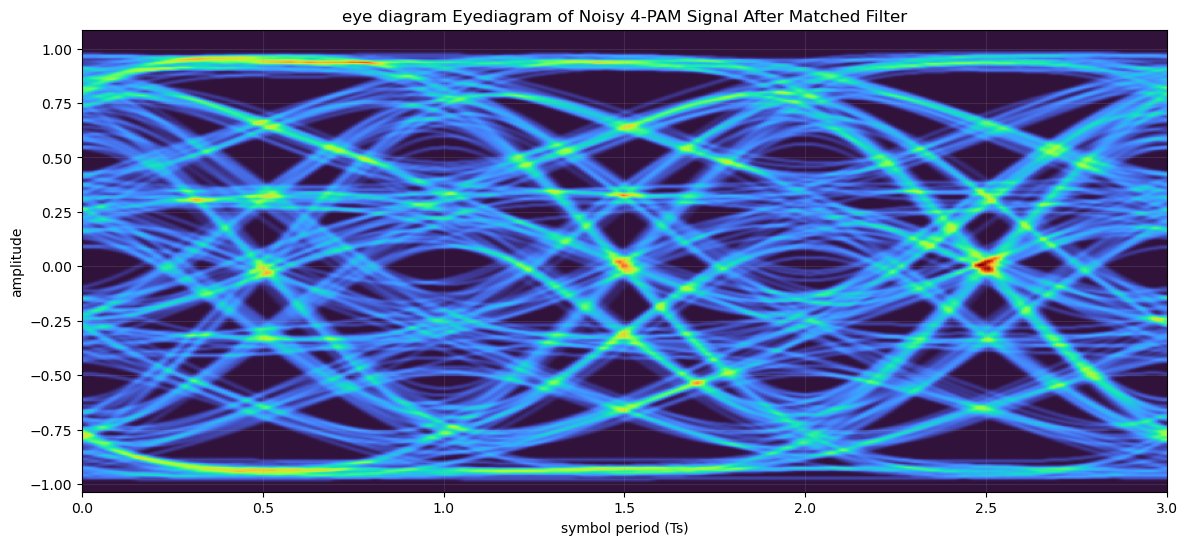

In [154]:
eyediagram(sigIn=RxSig_ADC, 
           Nsamples=len(RxSig_ADC), 
           SpS=SpS, 
           n=3,             # Number of "eyes" side by side (3 is the ideal default)
           ptype='fancy',   # 'fancy' heatmap
           plotlabel=f'Eyediagram of Noisy 4-PAM Signal After ADC'   )

eyediagram(sigIn=Rx_Filter_Matched, 
           Nsamples=len(Rx_Filter_Matched),
           SpS=SpS,
           n=3,             # Number of "eyes" side by side (3 is the ideal default)
           ptype='fancy',   # 'fancy' heatmap
           plotlabel=f'Eyediagram of Noisy 4-PAM Signal After Matched Filter')